#  Model Building

## Student Mental Health Prediction

### Objectif

Après les étapes de Data Understanding, d'Exploratory Data Analysis et de Data Preparation, cette phase consiste à construire plusieurs modèles de Machine Learning capables de prédire la variable cible `Depression`.

Le problème étudié est un problème de classification binaire :

- `0` : absence de dépression ;
- `1` : présence de dépression.

Plusieurs algorithmes de classification seront entraînés et comparés afin d'identifier le modèle offrant le meilleur compromis entre performance, capacité de généralisation et interprétabilité.

Une attention particulière sera accordée au Recall, car dans le contexte de la détection des étudiants potentiellement à risque, il est important de limiter le nombre de cas réellement positifs qui ne seraient pas détectés par le modèle.

In [48]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

In [49]:
X_train = pd.read_csv("../dataset/processed/X_train.csv")
X_test = pd.read_csv("../dataset/processed/X_test.csv")

y_train = pd.read_csv("../dataset/processed/y_train.csv").squeeze()
y_test = pd.read_csv("../dataset/processed/y_test.csv").squeeze()

In [50]:
print("X_train :", X_train.shape)
print("X_test  :", X_test.shape)
print("y_train :", y_train.shape)
print("y_test  :", y_test.shape)

X_train : (22318, 15)
X_test  : (5580, 15)
y_train : (22318,)
y_test  : (5580,)


In [51]:
print(y_train.value_counts())
print()
print(y_train.value_counts(normalize=True))

Depression
1    13068
0     9250
Name: count, dtype: int64

Depression
1    0.585536
0    0.414464
Name: proportion, dtype: float64


In [52]:

model1_lr=LogisticRegression(max_iter=1000,random_state=42)


In [53]:
model1_lr.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [54]:
y_pred = model1_lr.predict(X_test)

print(y_pred[:20])

[1 1 0 0 1 1 0 1 1 0 0 0 0 1 1 1 1 1 1 1]


In [55]:
y_proba = model1_lr.predict_proba(X_test)

print(y_proba[:10])

[[0.05006817 0.94993183]
 [0.03449502 0.96550498]
 [0.99632784 0.00367216]
 [0.83792426 0.16207574]
 [0.00405775 0.99594225]
 [0.05323422 0.94676578]
 [0.84429277 0.15570723]
 [0.01427571 0.98572429]
 [0.0232407  0.9767593 ]
 [0.97035143 0.02964857]]


In [56]:
accuracy_lr = accuracy_score(y_test, y_pred)

print("Accuracy :", accuracy_lr)

Accuracy : 0.8458781362007168


In [57]:
precision_lr = precision_score(y_test, y_pred)

print("Precision :", precision_lr)

Precision : 0.8578650014867678


In [58]:
recall_lr = recall_score(y_test, y_pred)

print("Recall :", recall_lr)

Recall : 0.8830731558004286


In [59]:
f1_lr = f1_score(y_test, y_pred)

print("F1-score :", f1_lr)

F1-score : 0.8702865761689291


In [60]:
roc_auc_lr = roc_auc_score(y_test, y_proba[:, 1])

print("ROC-AUC :", roc_auc_lr)

ROC-AUC : 0.9184516363308173


In [61]:
cm_lr = confusion_matrix(y_test, y_pred)

print(cm_lr)

[[1835  478]
 [ 382 2885]]


In [62]:
accuracy_lr = accuracy_score(y_test, y_pred)
precision_lr = precision_score(y_test, y_pred)
recall_lr = recall_score(y_test, y_pred)
f1_lr = f1_score(y_test, y_pred)
roc_auc_lr = roc_auc_score(y_test, y_proba[:, 1])

print("Accuracy :", accuracy_lr)
print("Precision:", precision_lr)
print("Recall   :", recall_lr)
print("F1-score :", f1_lr)
print("ROC-AUC  :", roc_auc_lr)

Accuracy : 0.8458781362007168
Precision: 0.8578650014867678
Recall   : 0.8830731558004286
F1-score : 0.8702865761689291
ROC-AUC  : 0.9184516363308173


In [63]:
cm_lr = confusion_matrix(y_test, y_pred)

print(cm_lr)

[[1835  478]
 [ 382 2885]]


In [64]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.83      0.79      0.81      2313
           1       0.86      0.88      0.87      3267

    accuracy                           0.85      5580
   macro avg       0.84      0.84      0.84      5580
weighted avg       0.85      0.85      0.85      5580



### Interprétation des résultats

La Régression Logistique obtient une Accuracy de 84,59 %, ce qui signifie qu'environ 85 % des observations du jeu de test sont correctement classées.

La Precision atteint 85,79 %, indiquant que la majorité des étudiants prédits comme présentant une dépression appartiennent effectivement à cette classe.

Le Recall atteint 88,31 %. Cette métrique est particulièrement importante dans le cadre de notre projet, car elle mesure la capacité du modèle à identifier les étudiants appartenant réellement à la classe `Depression = 1`. Le modèle détecte ainsi environ 88 % des cas positifs.

Le F1-score atteint 87,03 %, traduisant un compromis satisfaisant entre la Precision et le Recall.

Enfin, le ROC-AUC de 91,85 % indique une bonne capacité du modèle à distinguer les deux classes.

La matrice de confusion montre que 2 885 observations positives sont correctement identifiées (True Positives), tandis que 382 observations positives ne sont pas détectées (False Negatives). Ces dernières constituent un point d'attention particulier dans le contexte du projet, car elles correspondent à des cas potentiellement à risque qui ne seraient pas identifiés par le modèle.

Ces résultats constituent une première référence pour la comparaison avec les autres modèles de classification.

## 2. Decision Tree

### Objectif

Le Decision Tree est un algorithme de classification qui construit une succession de règles permettant de séparer les observations selon leur classe.

Contrairement à la Régression Logistique, qui modélise une relation entre les variables explicatives et la probabilité de la classe cible, un arbre de décision peut capturer des relations non linéaires et des interactions entre les variables.

Dans notre projet, le Decision Tree sera utilisé afin de comparer un modèle basé sur des règles de décision avec la Régression Logistique.

In [65]:
from sklearn.tree import DecisionTreeClassifier

In [66]:
model2_dt = DecisionTreeClassifier(
    random_state=42
)

In [67]:
model2_dt.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

In [68]:
y_pred_dt = model2_dt.predict(X_test)

In [69]:
y_proba_dt = model2_dt.predict_proba(X_test)[:, 1]

In [70]:
accuracy_dt = accuracy_score(y_test, y_pred_dt)
precision_dt = precision_score(y_test, y_pred_dt)
recall_dt = recall_score(y_test, y_pred_dt)
f1_dt = f1_score(y_test, y_pred_dt)
roc_auc_dt = roc_auc_score(y_test, y_proba_dt)

print("Decision Tree")
print("-----------------------")
print("Accuracy :", accuracy_dt)
print("Precision:", precision_dt)
print("Recall   :", recall_dt)
print("F1-score :", f1_dt)
print("ROC-AUC  :", roc_auc_dt)

Decision Tree
-----------------------
Accuracy : 0.7663082437275985
Precision: 0.8011660018410556
Recall   : 0.7992041628405264
F1-score : 0.8001838798651547
ROC-AUC  : 0.7595242604085901


In [71]:
print(confusion_matrix(y_test, y_pred_dt))

[[1665  648]
 [ 656 2611]]


In [72]:
print(classification_report(y_test, y_pred_dt))

              precision    recall  f1-score   support

           0       0.72      0.72      0.72      2313
           1       0.80      0.80      0.80      3267

    accuracy                           0.77      5580
   macro avg       0.76      0.76      0.76      5580
weighted avg       0.77      0.77      0.77      5580



### Interprétation des résultats

Le Decision Tree obtient une Accuracy de 76,63 %, une Precision de 80,12 %, un Recall de 79,92 %, un F1-score de 80,02 % et un ROC-AUC de 75,95 %.

Ces performances sont inférieures à celles obtenues précédemment avec la Régression Logistique. En particulier, le Recall du Decision Tree atteint 79,92 %, contre 88,31 % pour la Régression Logistique. Cette différence est importante dans le contexte de notre projet, car le Recall mesure la capacité du modèle à détecter les étudiants appartenant réellement à la classe `Depression = 1`.

La matrice de confusion montre que le Decision Tree identifie correctement 2 611 observations positives, mais produit également 656 faux négatifs. Ces observations correspondent à des étudiants réellement dépressifs mais classés comme non dépressifs par le modèle.

À ce stade, la Régression Logistique présente donc de meilleures performances globales que le Decision Tree. Cependant, cette comparaison correspond aux configurations initiales des modèles. Une optimisation ultérieure des hyperparamètres pourra être réalisée afin d'évaluer si les performances du Decision Tree peuvent être améliorées.

## 3. Random Forest

### Objectif

Random Forest est une méthode d'ensemble basée sur la combinaison de plusieurs arbres de décision.

Contrairement au Decision Tree, qui repose sur un seul arbre, Random Forest construit plusieurs arbres et combine leurs prédictions afin d'obtenir une décision finale plus robuste.

Cette approche permet notamment de réduire la sensibilité d'un arbre individuel aux particularités des données d'entraînement et de mieux capturer des relations non linéaires entre les variables.

Dans notre projet, Random Forest sera utilisé comme troisième modèle de classification et sera comparé à la Régression Logistique et au Decision Tree.

In [73]:
model3_rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

In [74]:
model3_rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [75]:
y_pred_rf = model3_rf.predict(X_test)

In [76]:
y_proba_rf = model3_rf.predict_proba(X_test)

In [77]:
accuracy_rf = accuracy_score(y_test, y_pred_rf)

precision_rf = precision_score(y_test, y_pred_rf)

recall_rf = recall_score(y_test, y_pred_rf)

f1_rf = f1_score(y_test, y_pred_rf)

roc_auc_rf = roc_auc_score(
    y_test,
    y_proba_rf[:, 1]
)

In [78]:
print("Random Forest")
print("-----------------------")
print("Accuracy :", accuracy_rf)
print("Precision:", precision_rf)
print("Recall   :", recall_rf)
print("F1-score :", f1_rf)
print("ROC-AUC  :", roc_auc_rf)

Random Forest
-----------------------
Accuracy : 0.8378136200716846
Precision: 0.8489952718676123
Recall   : 0.879400061218243
F1-score : 0.8639302360547286
ROC-AUC  : 0.9111323112030575


In [79]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

print(cm_rf)

[[1802  511]
 [ 394 2873]]


In [80]:
y_train_pred_rf = model3_rf.predict(X_train)

train_accuracy_rf = accuracy_score(
    y_train,
    y_train_pred_rf
)

test_accuracy_rf = accuracy_score(
    y_test,
    y_pred_rf
)

print("Train Accuracy :", train_accuracy_rf)
print("Test Accuracy  :", test_accuracy_rf)

Train Accuracy : 1.0
Test Accuracy  : 0.8378136200716846


### Interprétation des résultats

Le modèle Random Forest obtient une Accuracy de 83,78 %, une Precision de 84,90 %, un Recall de 87,94 %, un F1-score de 86,39 % et un ROC-AUC de 91,13 %.

Ces résultats montrent que Random Forest possède de bonnes performances pour prédire la dépression chez les étudiants. Le Recall de 87,94 % est particulièrement intéressant dans le contexte de notre projet, car le modèle réussit à détecter environ 88 % des étudiants réellement classés comme dépressifs.

Le modèle Random Forest est également nettement plus performant que le Decision Tree utilisé précédemment. Ses performances restent toutefois légèrement inférieures à celles de la Logistic Regression dans cette configuration initiale.

Ces résultats seront conservés pour la comparaison finale avec les autres modèles, notamment KNN et les modèles qui seront étudiés par la suite.

## 4. K-Nearest Neighbors (KNN)

### Objectif

K-Nearest Neighbors (KNN) est un algorithme de classification basé sur la proximité entre les observations.

Pour prédire la classe d'une nouvelle observation, l'algorithme identifie les K observations les plus proches selon une mesure de distance, puis attribue la classe majoritaire parmi ces voisins.

Contrairement aux modèles précédents, KNN repose directement sur les distances entre les observations. La standardisation des variables est donc particulièrement importante afin d'éviter qu'une variable possédant une échelle plus importante domine le calcul des distances.

Dans notre projet, KNN sera utilisé comme modèle de comparaison avec les approches précédentes.

In [81]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [82]:
model4_knn = KNeighborsClassifier(
    n_neighbors=5
)

In [83]:
model4_knn.fit(
    X_train_scaled,
    y_train
)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [84]:
y_pred_knn = model4_knn.predict(
    X_test_scaled
)

In [85]:
y_proba_knn = model4_knn.predict_proba(
    X_test_scaled
)

In [86]:
accuracy_knn = accuracy_score(
    y_test,
    y_pred_knn
)

precision_knn = precision_score(
    y_test,
    y_pred_knn
)

recall_knn = recall_score(
    y_test,
    y_pred_knn
)

f1_knn = f1_score(
    y_test,
    y_pred_knn
)

roc_auc_knn = roc_auc_score(
    y_test,
    y_proba_knn[:, 1]
)

In [87]:
print("KNN")
print("-----------------------")
print("Accuracy :", accuracy_knn)
print("Precision:", precision_knn)
print("Recall   :", recall_knn)
print("F1-score :", f1_knn)
print("ROC-AUC  :", roc_auc_knn)

KNN
-----------------------
Accuracy : 0.8168458781362007
Precision: 0.8308281756557618
Recall   : 0.8628711355984083
F1-score : 0.8465465465465466
ROC-AUC  : 0.8764742632604127


In [88]:
cm_knn = confusion_matrix(
    y_test,
    y_pred_knn
)

print(cm_knn)

[[1739  574]
 [ 448 2819]]


### Interprétation des résultats

Le modèle KNN, avec `K = 5`, obtient une Accuracy de 81,65 %, une Precision de 83,08 %, un Recall de 86,83 %, un F1-score de 84,65 % et un ROC-AUC de 87,67 %.

Le Recall de 86,83 % indique que le modèle réussit à détecter environ 87 % des étudiants réellement classés comme dépressifs. Cette métrique est particulièrement importante dans le contexte de notre projet.

La matrice de confusion montre que 2 819 observations positives sont correctement identifiées, tandis que 448 observations positives sont classées à tort comme négatives.

Par rapport aux autres modèles testés, KNN présente des performances intermédiaires. Il est meilleur que le Decision Tree, mais reste légèrement inférieur à la Logistic Regression et au Random Forest dans cette configuration initiale.

Ces résultats seront utilisés pour la comparaison globale des modèles avant l'étape d'optimisation des hyperparamètres.

un tableau comparatif des 4 modeles 

In [89]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "KNN"
    ],
    "Accuracy": [
        accuracy_lr,
        accuracy_dt,
        accuracy_rf,
        accuracy_knn
    ],
    "Precision": [
        precision_lr,
        precision_dt,
        precision_rf,
        precision_knn
    ],
    "Recall": [
        recall_lr,
        recall_dt,
        recall_rf,
        recall_knn
    ],
    "F1-score": [
        f1_lr,
        f1_dt,
        f1_rf,
        f1_knn
    ],
    "ROC-AUC": [
        roc_auc_lr,
        roc_auc_dt,
        roc_auc_rf,
        roc_auc_knn
    ]
})

results

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Logistic Regression,0.845878,0.857865,0.883073,0.870287,0.918452
1,Decision Tree,0.766308,0.801166,0.799204,0.800184,0.759524
2,Random Forest,0.837814,0.848995,0.879400,0.863930,0.911132
3,KNN,0.816846,0.830828,0.862871,0.846547,0.876474


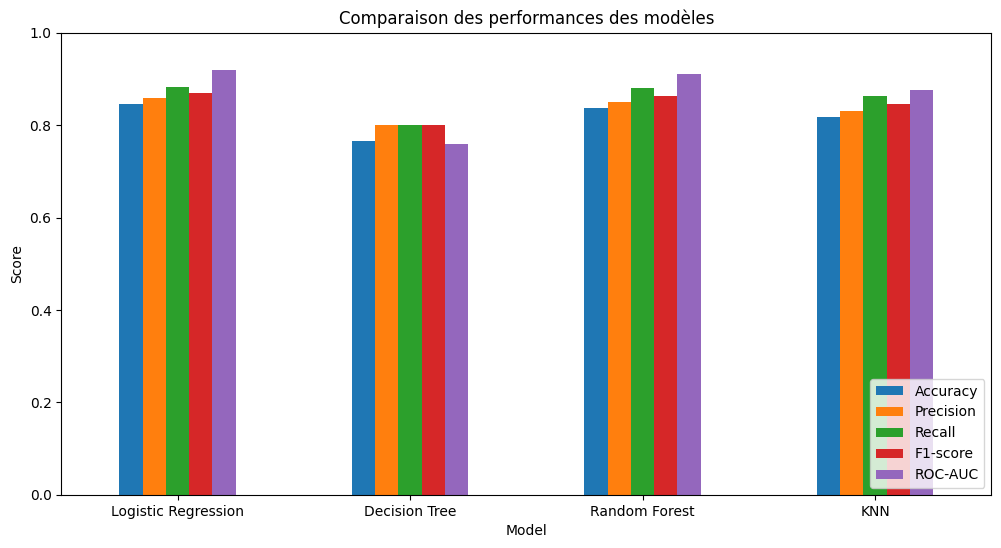

In [90]:
results.set_index("Model").plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Comparaison des performances des modèles")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.show()


verifions l'overfitting 

In [91]:
y_train_pred_lr = model1_lr.predict(X_train)

train_accuracy_lr = accuracy_score(
    y_train,
    y_train_pred_lr
)

print("Logistic Regression")
print("Train Accuracy :", train_accuracy_lr)
print("Test Accuracy  :", accuracy_lr)

Logistic Regression
Train Accuracy : 0.8470293037010485
Test Accuracy  : 0.8458781362007168


In [92]:
y_train_pred_dt = model2_dt.predict(X_train)

train_accuracy_dt = accuracy_score(
    y_train,
    y_train_pred_dt
)

print("Decision Tree")
print("Train Accuracy :", train_accuracy_dt)
print("Test Accuracy  :", accuracy_dt)

Decision Tree
Train Accuracy : 1.0
Test Accuracy  : 0.7663082437275985


In [93]:
y_train_pred_rf = model3_rf.predict(X_train)

train_accuracy_rf = accuracy_score(
    y_train,
    y_train_pred_rf
)

print("Random Forest")
print("Train Accuracy :", train_accuracy_rf)
print("Test Accuracy  :", accuracy_rf)

Random Forest
Train Accuracy : 1.0
Test Accuracy  : 0.8378136200716846


In [ ]:
y_train_pred_knn = model4_knn.predict(X_train_scaled)

train_accuracy_knn = accuracy_score(
    y_train,
    y_train_pred_knn
)

print("KNN")
print("Train Accuracy :", train_accuracy_knn)
print("Test Accuracy  :", accuracy_knn)